In [17]:

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math
print("lib loaded")

  Using cached python_docx-1.2.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached lxml-6.0.2-cp313-cp313-win_amd64.whl.metadata (3.7 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached python_docx-1.2.0-py3-none-any.whl (252 kB)
Using cached lxml-6.0.2-cp313-cp313-win_amd64.whl (4.0 MB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   -------------------------- ------------- 2/3 [python-docx]
   -------------------------- ------------- 2/3 [python-docx]
   -------------------------- ------------- 2/3 [python-docx]
   -------------------------- ------------- 2/3 [python-docx]
   -------------------------- ------------- 2/3 [python-docx]
   -------------------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
dataset=pd.read_csv("students_mental_health_survey.csv")
dataset.head()
dataset.info()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7022 entries, 0 to 7021
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   7022 non-null   int64  
 1   Age                          7022 non-null   int64  
 2   Course                       7022 non-null   object 
 3   Gender                       7022 non-null   object 
 4   CGPA                         7010 non-null   float64
 5   Stress_Level                 7022 non-null   int64  
 6   Depression_Score             7022 non-null   int64  
 7   Anxiety_Score                7022 non-null   int64  
 8   Sleep_Quality                7022 non-null   object 
 9   Physical_Activity            7022 non-null   object 
 10  Diet_Quality                 7022 non-null   object 
 11  Social_Support               7022 non-null   object 
 12  Relationship_Status          7022 non-null   object 
 13  Substance_Use     

(7022, 21)

In [7]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,7022.0,3511.500000,2027.221128,1.00,1756.25,3511.5,5266.75,7022.0
Age,7022.0,23.003418,3.853978,18.00,20.00,22.0,25.00,35.0
CGPA,7010.0,3.491270,0.287420,2.44,3.29,3.5,3.70,4.0
Stress_Level,7022.0,2.427941,1.638408,0.00,1.00,2.0,4.00,5.0
Depression_Score,7022.0,2.254486,1.625193,0.00,1.00,2.0,3.00,5.0
Anxiety_Score,7022.0,2.300484,1.624305,0.00,1.00,2.0,4.00,5.0
Financial_Stress,7022.0,2.453005,1.708995,0.00,1.00,2.0,4.00,5.0
Semester_Credit_Load,7022.0,22.010538,4.358380,15.00,18.00,22.0,26.00,29.0


In [8]:
dataset.isnull().sum()

Student_ID                      0
Age                             0
Course                          0
Gender                          0
CGPA                           12
Stress_Level                    0
Depression_Score                0
Anxiety_Score                   0
Sleep_Quality                   0
Physical_Activity               0
Diet_Quality                    0
Social_Support                  0
Relationship_Status             0
Substance_Use                  15
Counseling_Service_Use          0
Family_History                  0
Chronic_Illness                 0
Financial_Stress                0
Extracurricular_Involvement     0
Semester_Credit_Load            0
Residence_Type                  0
dtype: int64

In [9]:
dataset.nunique()

Student_ID                     7022
Age                              18
Course                            6
Gender                            2
CGPA                            143
Stress_Level                      6
Depression_Score                  6
Anxiety_Score                     6
Sleep_Quality                     3
Physical_Activity                 3
Diet_Quality                      3
Social_Support                    3
Relationship_Status               3
Substance_Use                     3
Counseling_Service_Use            3
Family_History                    2
Chronic_Illness                   2
Financial_Stress                  6
Extracurricular_Involvement       3
Semester_Credit_Load             15
Residence_Type                    3
dtype: int64

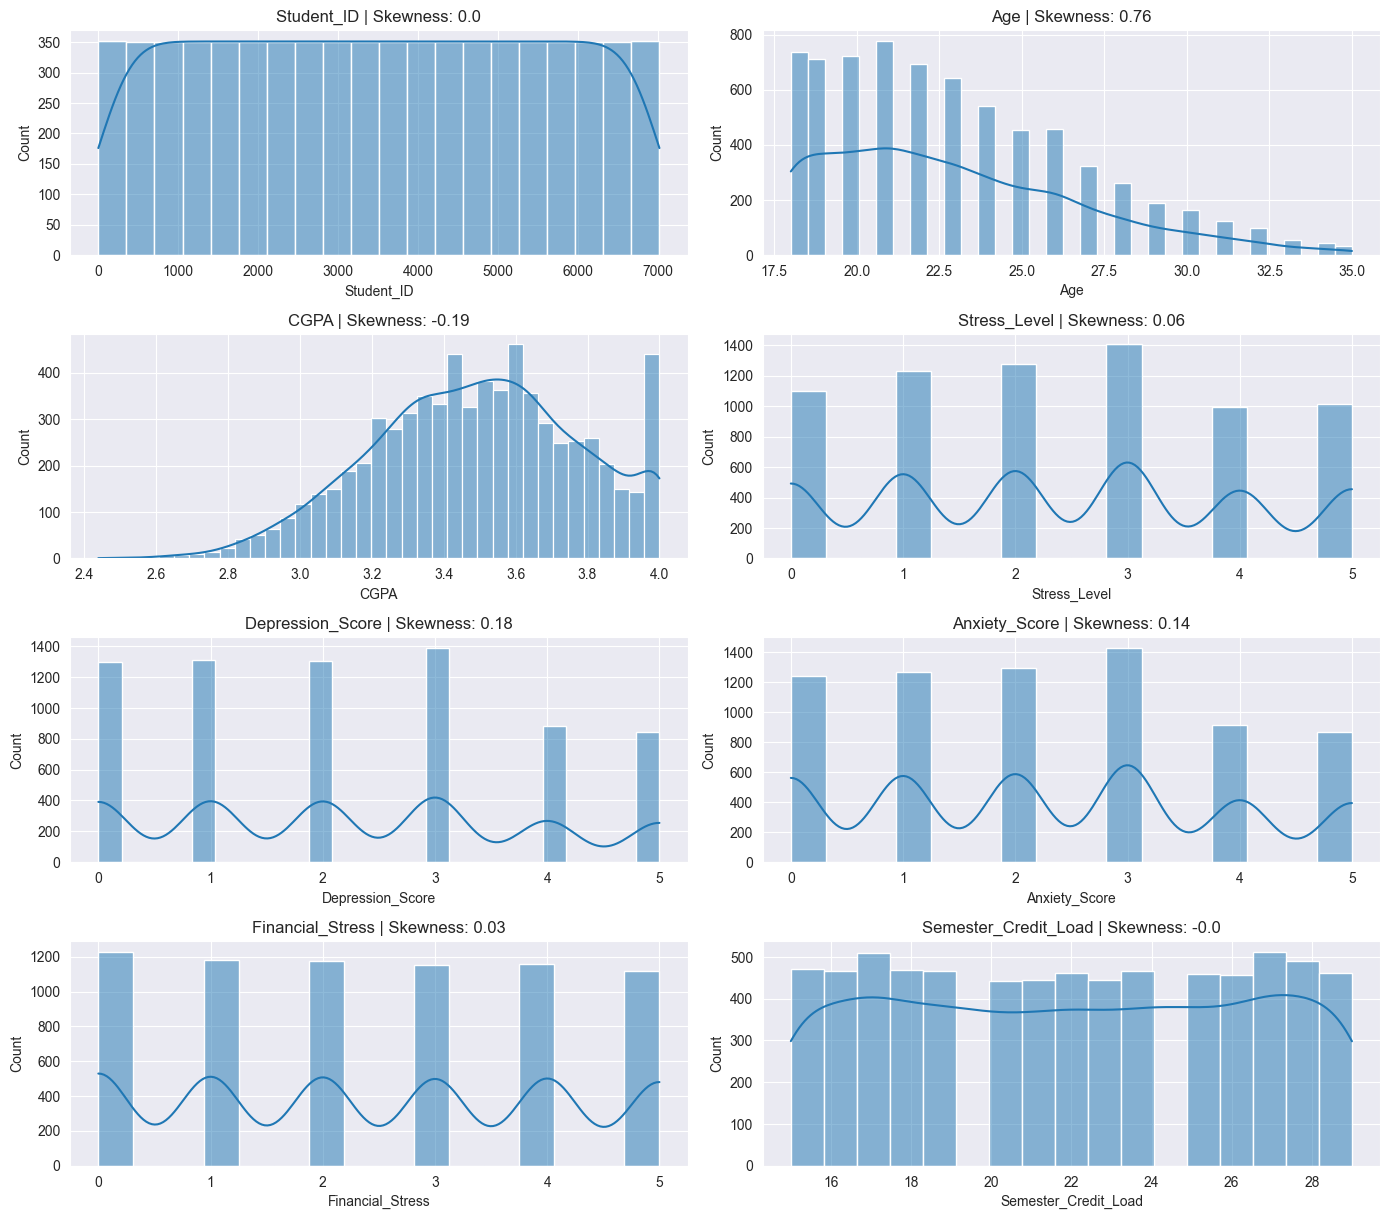

In [10]:
sns.set_style("darkgrid")

numerical_columns = dataset.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(dataset[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(dataset[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

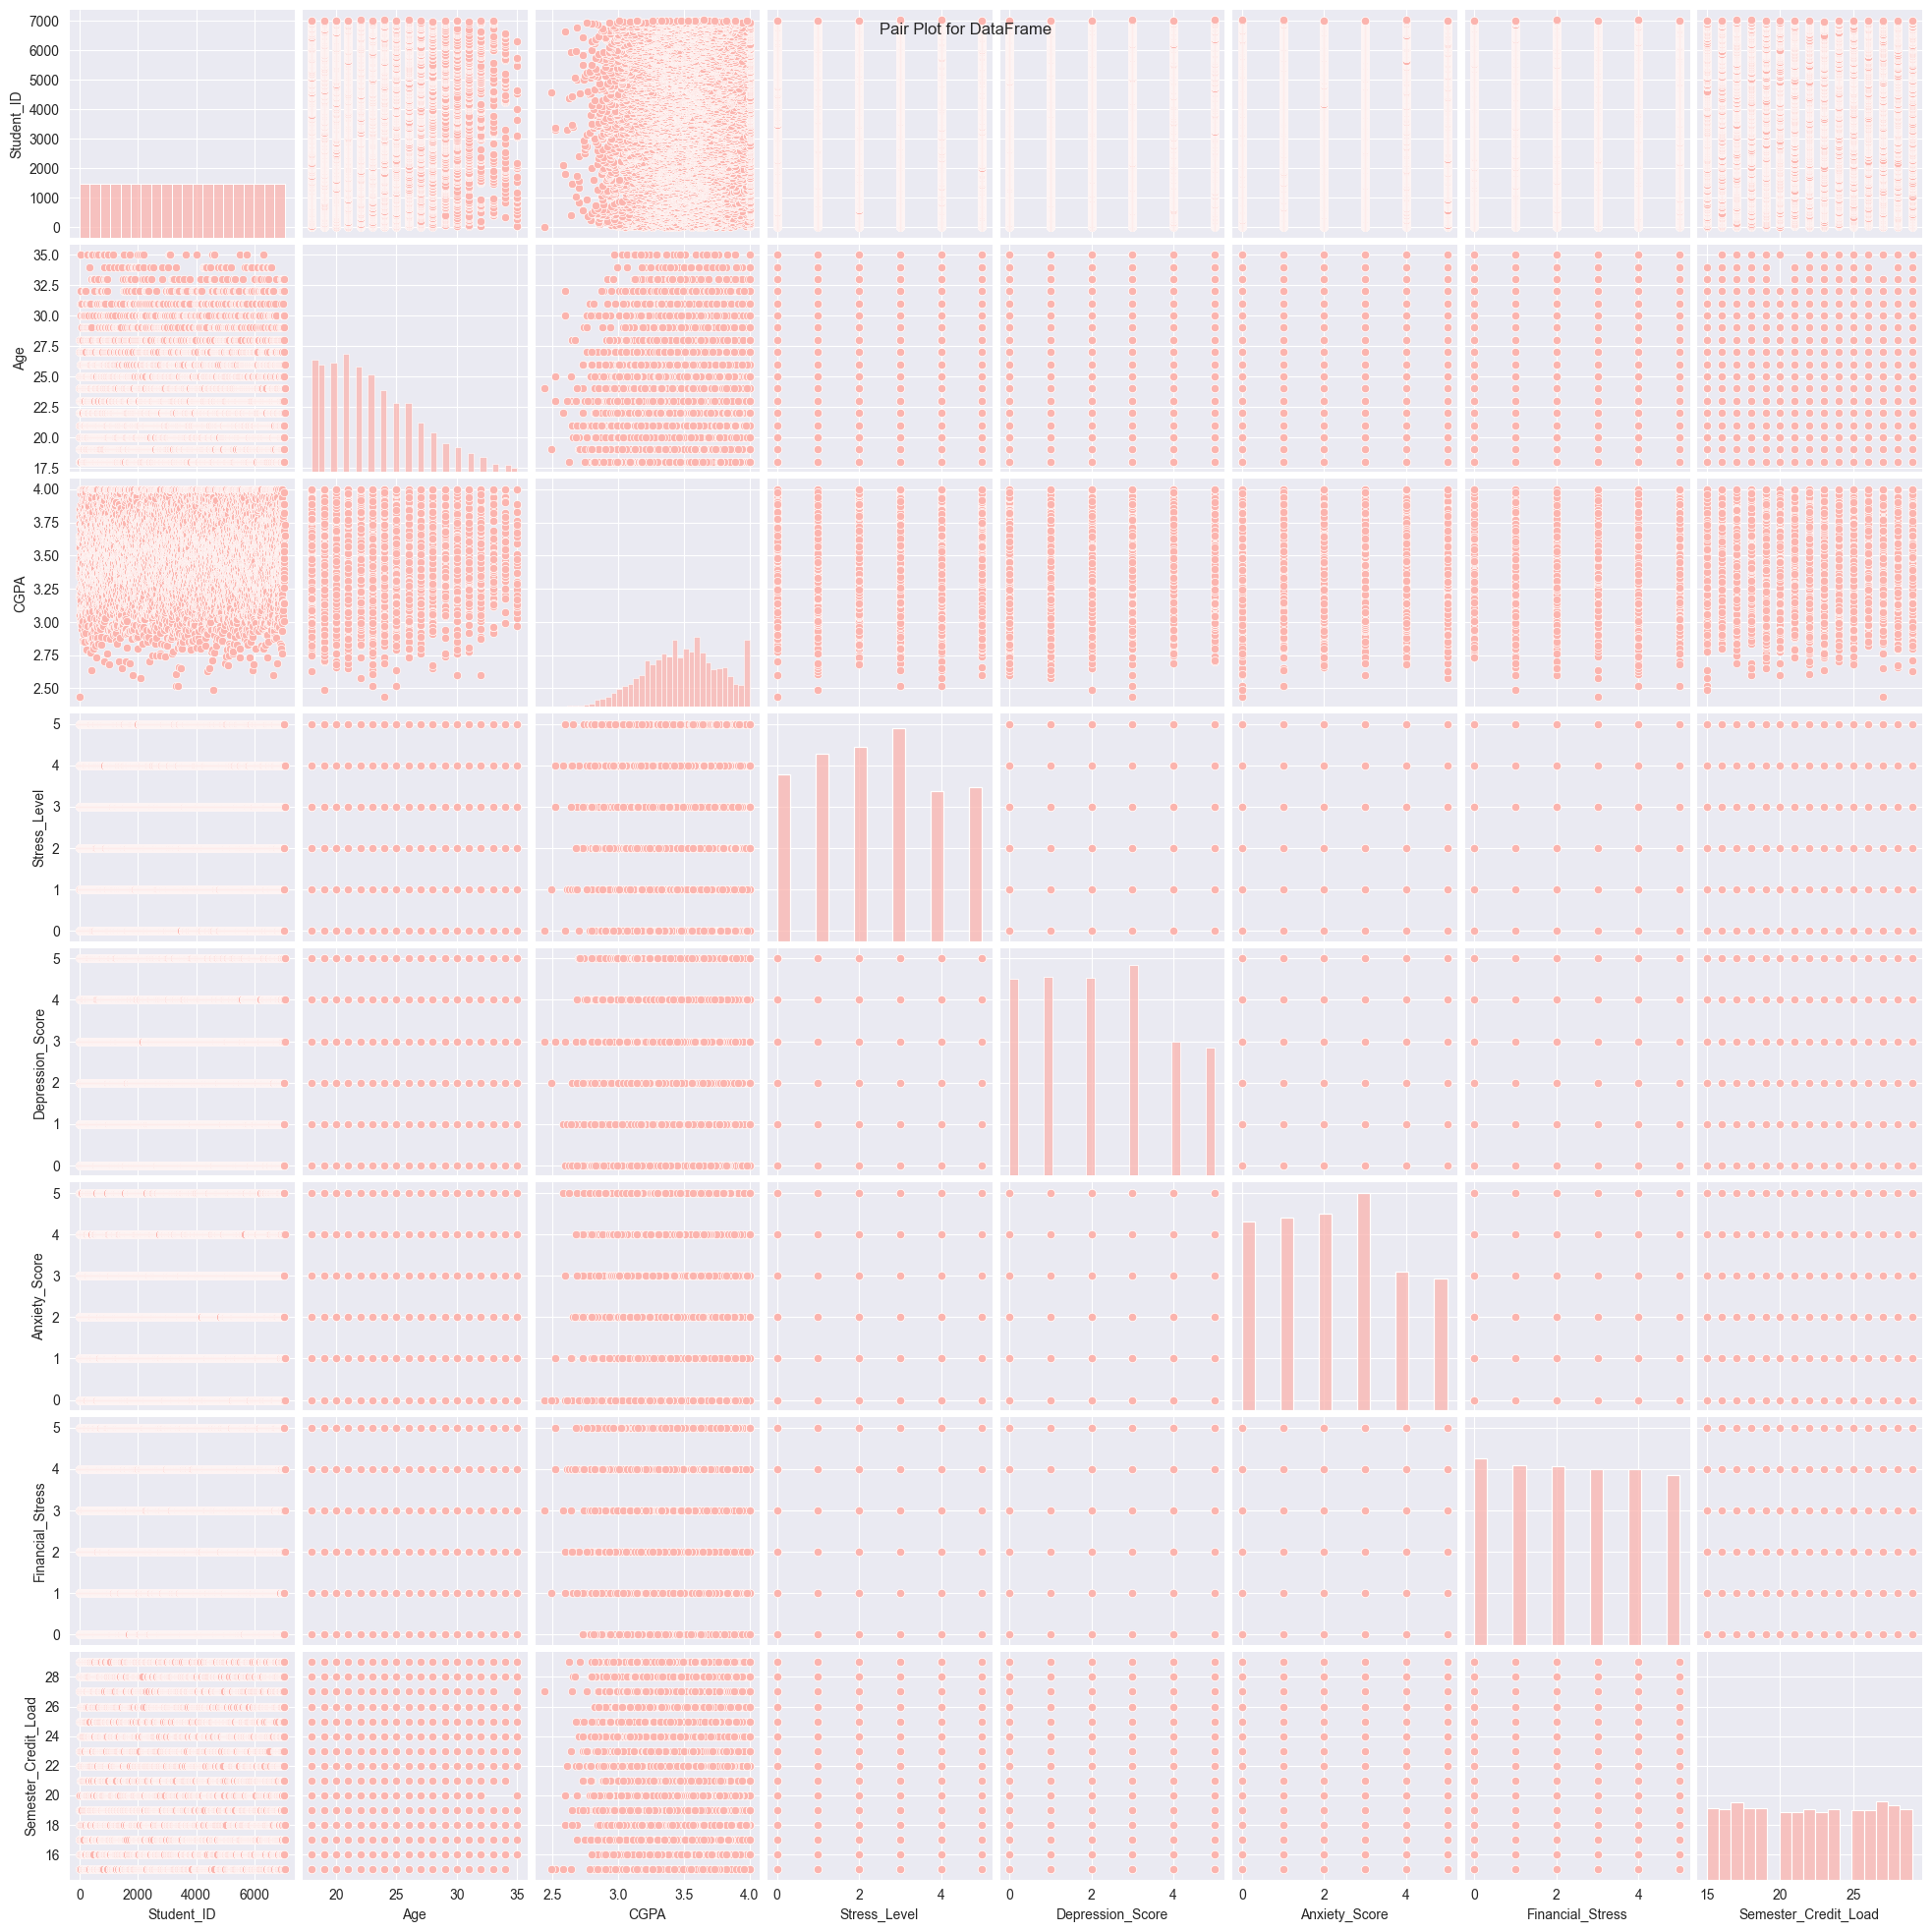

In [11]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(dataset)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

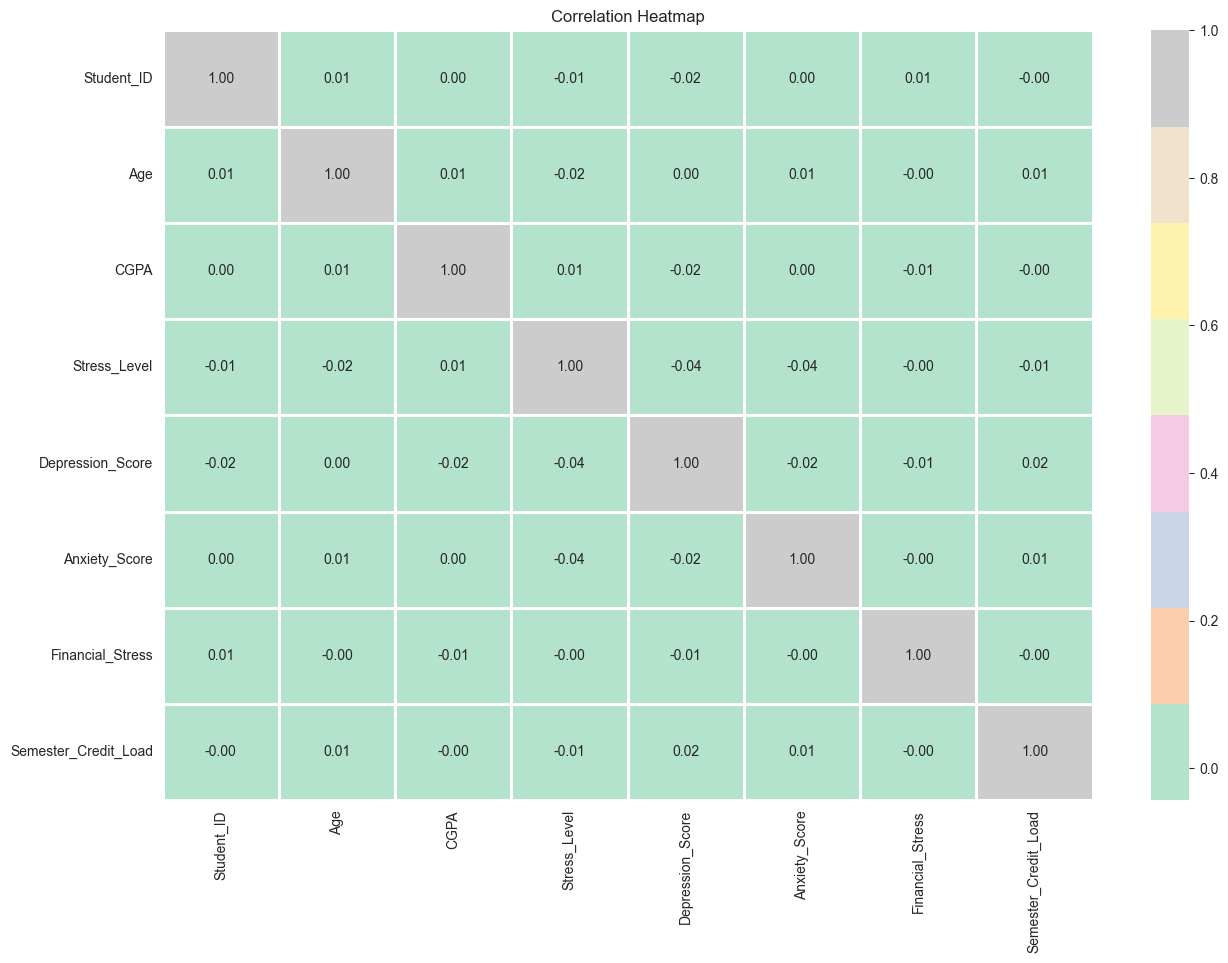

In [12]:
plt.figure(figsize=(15, 10))

# Select only numeric columns for correlation
numeric_data = dataset.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

Index(['Student_ID', 'Age', 'Course', 'Gender', 'CGPA', 'Stress_Level',
       'Depression_Score', 'Anxiety_Score', 'Sleep_Quality',
       'Physical_Activity', 'Diet_Quality', 'Social_Support',
       'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use',
       'Family_History', 'Chronic_Illness', 'Financial_Stress',
       'Extracurricular_Involvement', 'Semester_Credit_Load',
       'Residence_Type'],
      dtype='object')

Correlations with Stress Score:
Stress_Level            1.000000
CGPA                    0.005143
Financial_Stress       -0.001388
Semester_Credit_Load   -0.005558
Student_ID             -0.006190
Age                    -0.019901
Anxiety_Score          -0.035802
Depression_Score       -0.043313
Name: Stress_Level, dtype: float64


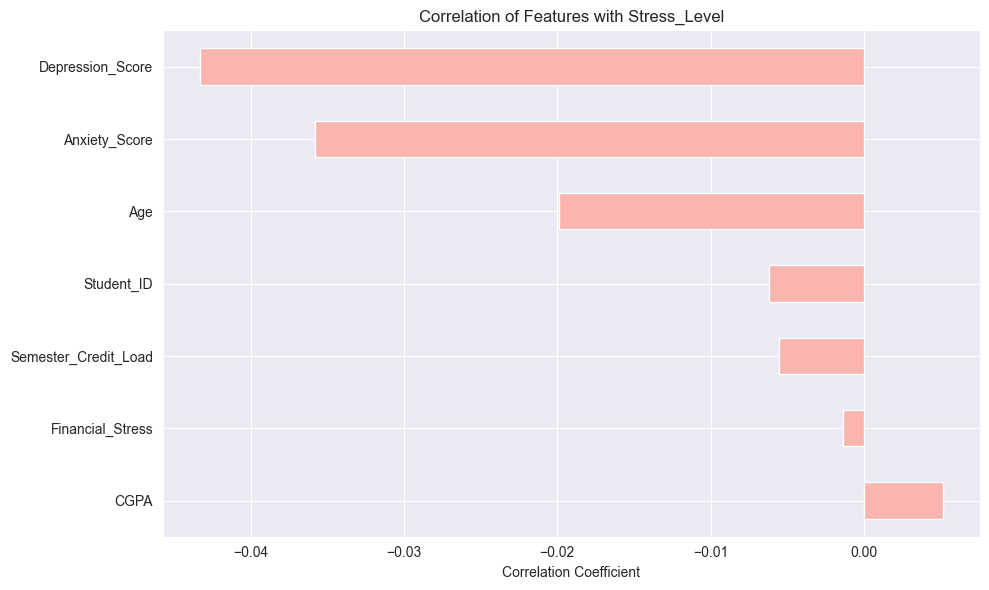

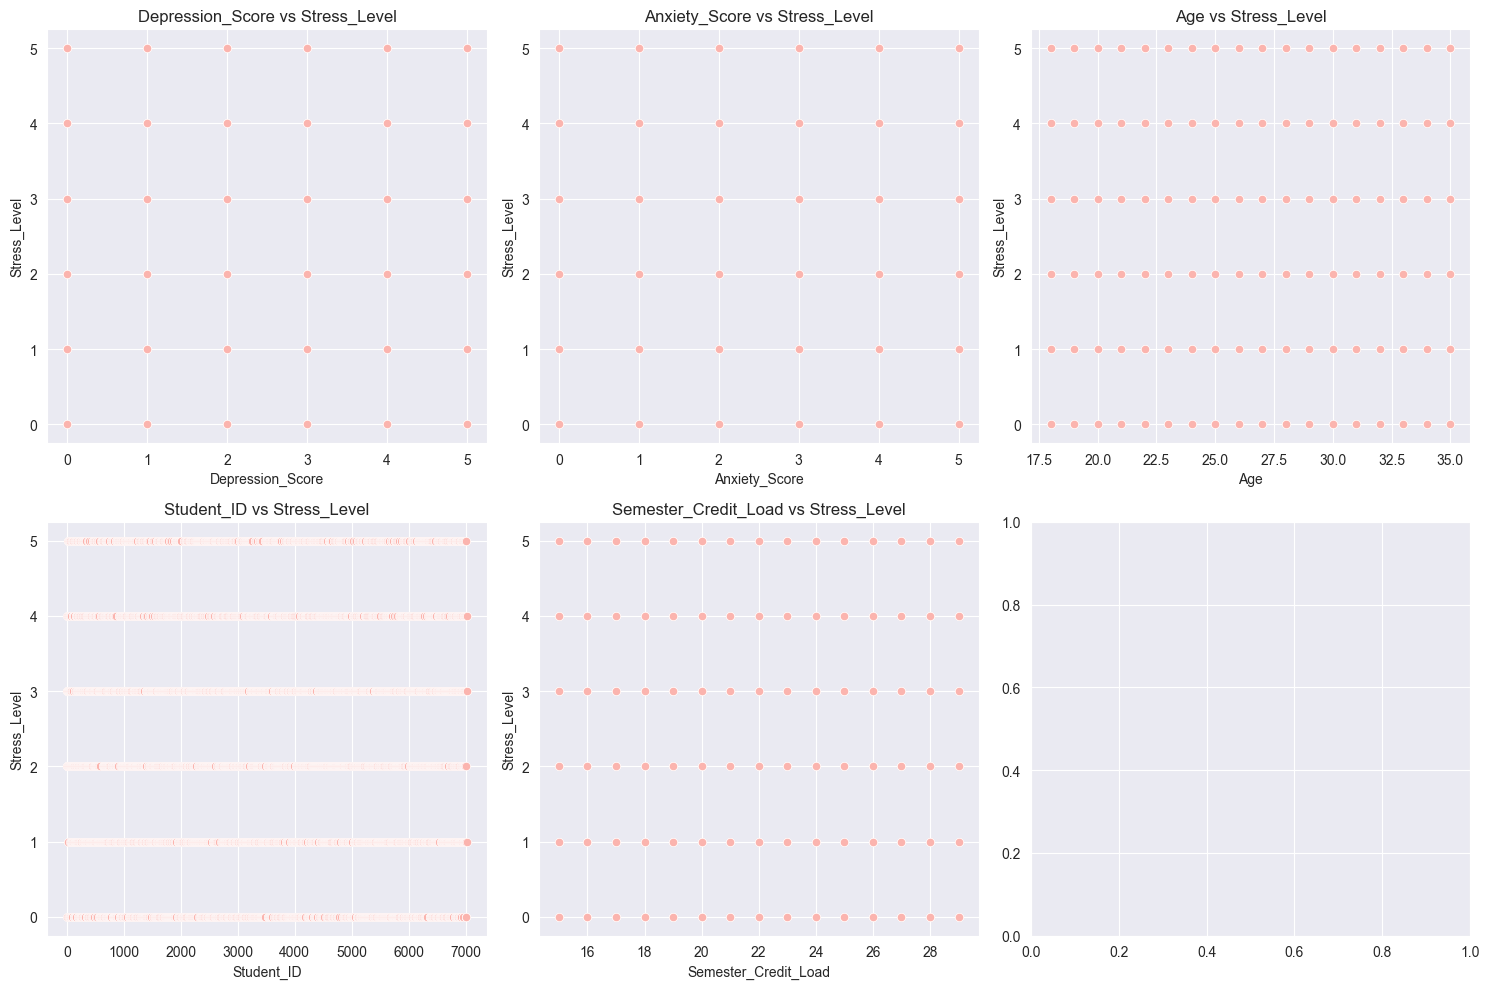

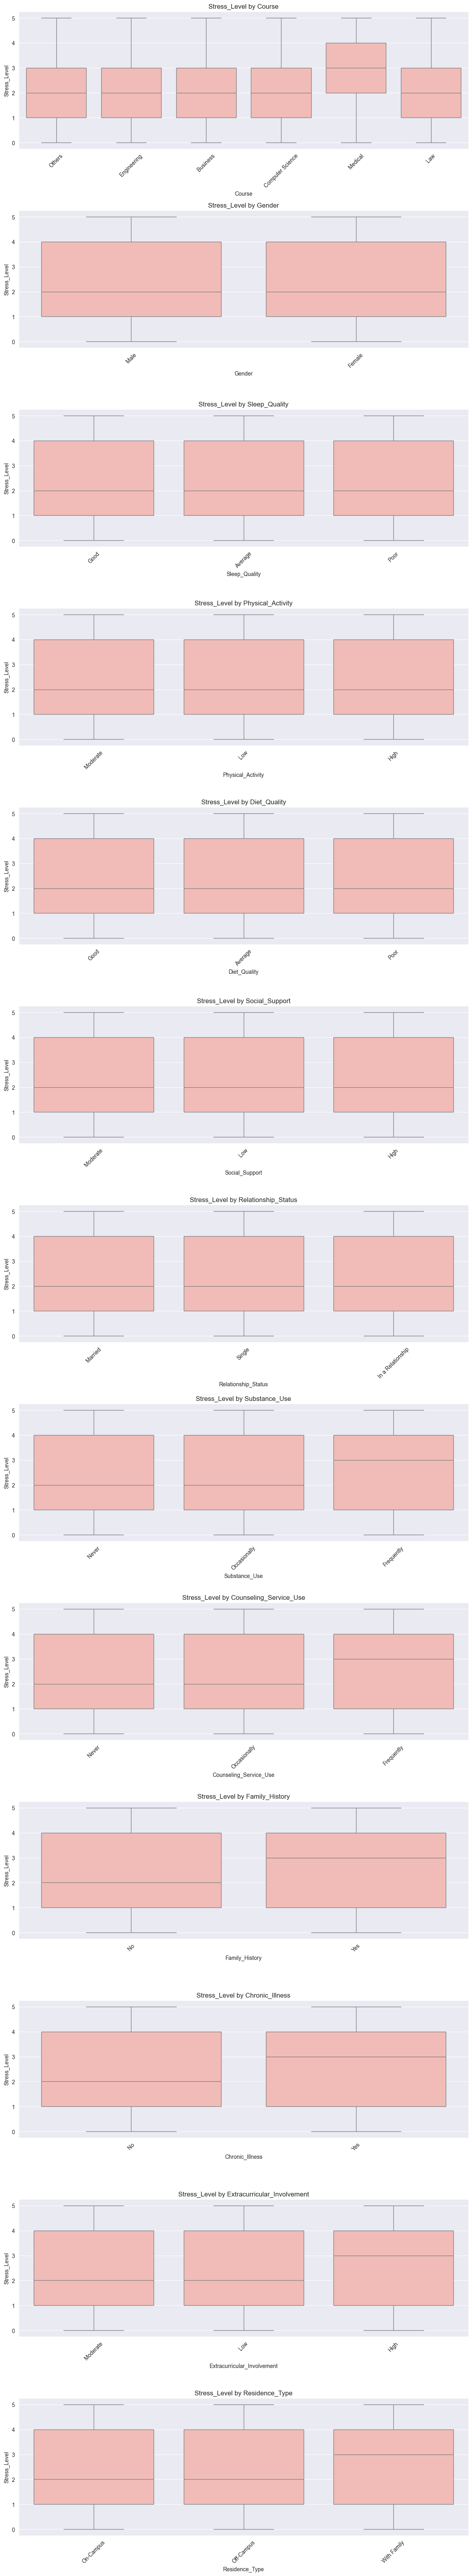

In [14]:
# Check if 'Stress_Score' column exists (adjust name if different)
# Common variations: 'Stress_Score', 'stress_score', 'Stress Score', etc.
print(dataset.columns)

# Assuming the stress score column exists, let's analyze relationships
stress_col = 'Stress_Level'  # Adjust this to your actual column name

# 1. Correlation with stress score
numeric_data = dataset.select_dtypes(include=[np.number])
stress_correlations = numeric_data.corr()[stress_col].sort_values(ascending=False)
print("\nCorrelations with Stress Score:")
print(stress_correlations)

# 2. Visualize correlations
plt.figure(figsize=(10, 6))
stress_correlations.drop(stress_col).plot(kind='barh')
plt.title(f'Correlation of Features with {stress_col}')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# 3. Scatter plots of top correlated features
top_features = stress_correlations.drop(stress_col).abs().nlargest(5).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    sns.scatterplot(data=dataset, x=feature, y=stress_col, ax=axes[idx])
    axes[idx].set_title(f'{feature} vs {stress_col}')

plt.tight_layout()
plt.show()

# 4. Box plots for categorical variables (if any)
categorical_cols = dataset.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5*len(categorical_cols)))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        sns.boxplot(data=dataset, x=col, y=stress_col, ax=axes[idx])
        axes[idx].set_title(f'{stress_col} by {col}')
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

Index(['Student_ID', 'Age', 'Course', 'Gender', 'CGPA', 'Stress_Level',
       'Depression_Score', 'Anxiety_Score', 'Sleep_Quality',
       'Physical_Activity', 'Diet_Quality', 'Social_Support',
       'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use',
       'Family_History', 'Chronic_Illness', 'Financial_Stress',
       'Extracurricular_Involvement', 'Semester_Credit_Load',
       'Residence_Type'],
      dtype='object')

Correlations with Depression Score:
Depression_Score        1.000000
Semester_Credit_Load    0.024234
Age                     0.000225
Financial_Stress       -0.012590
Anxiety_Score          -0.018019
Student_ID             -0.018554
CGPA                   -0.023100
Stress_Level           -0.043313
Name: Depression_Score, dtype: float64


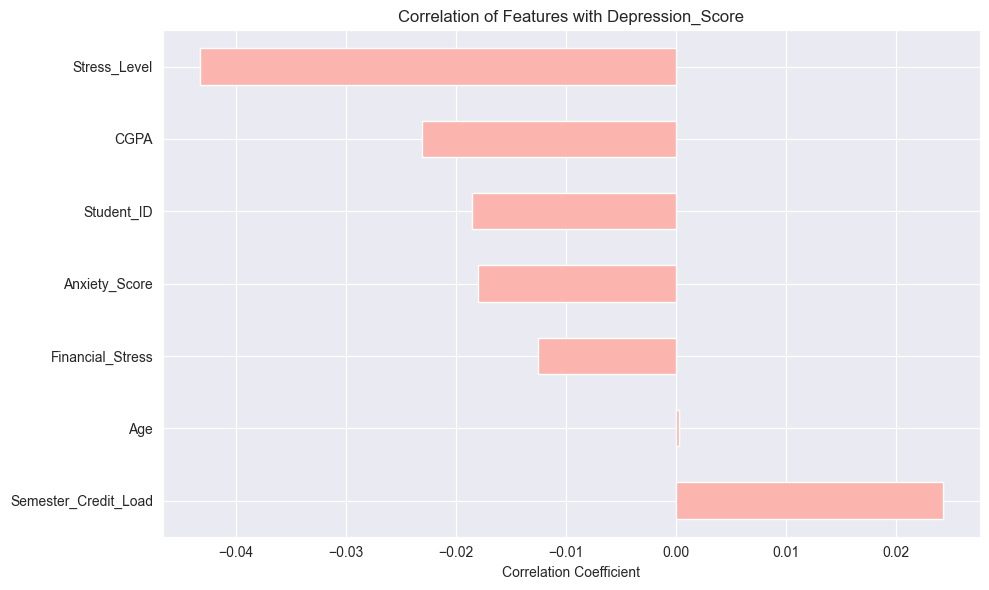

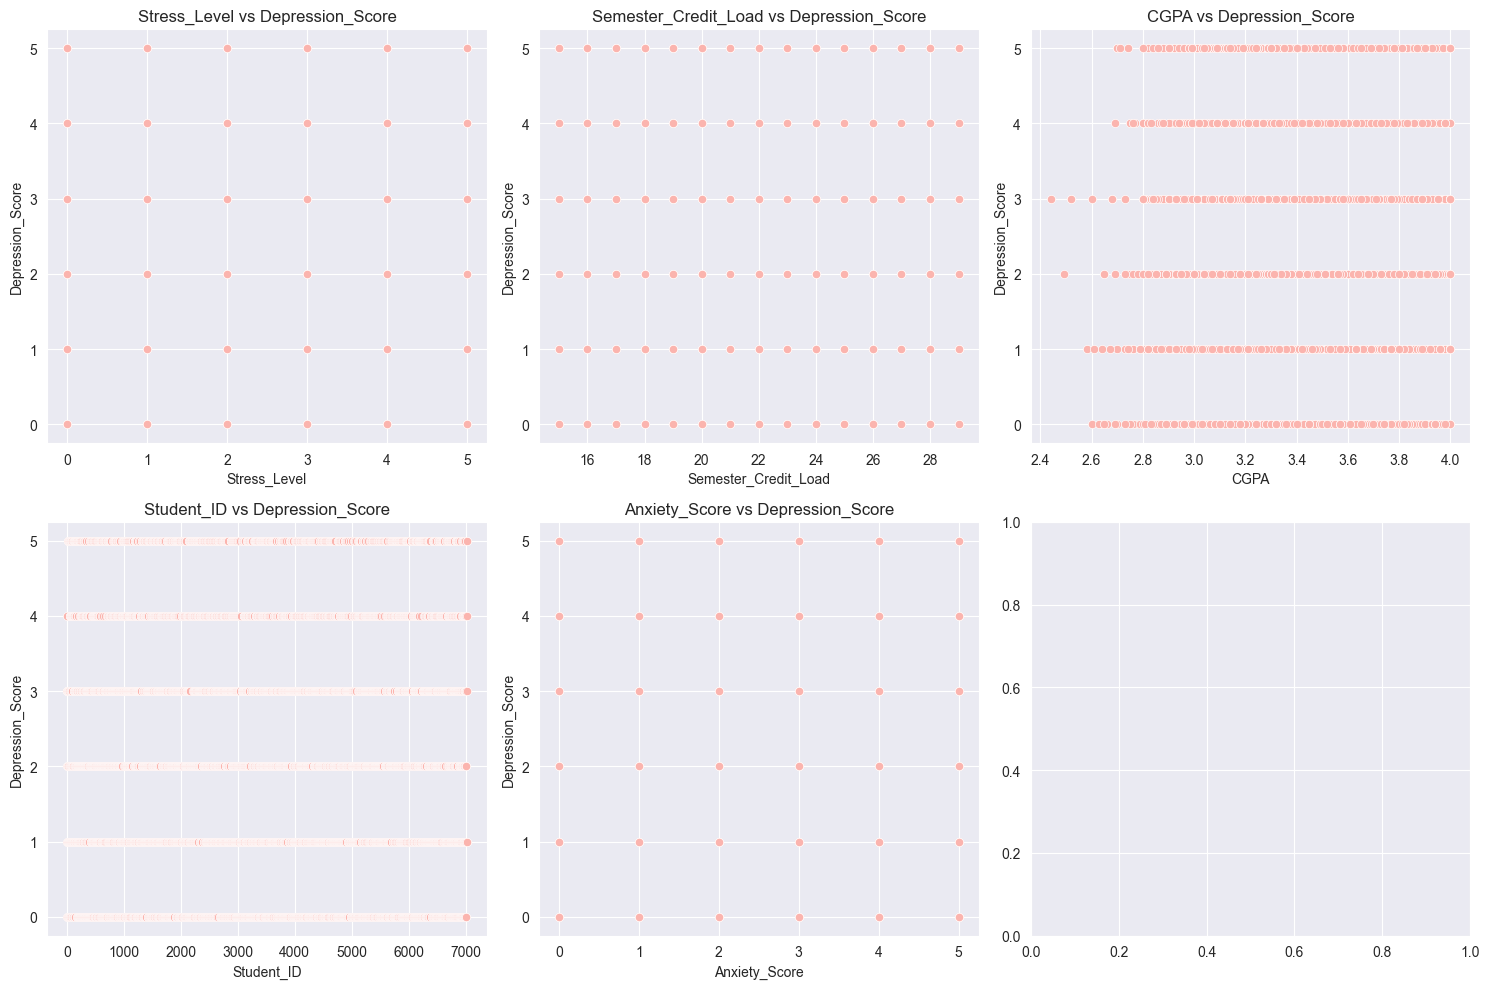

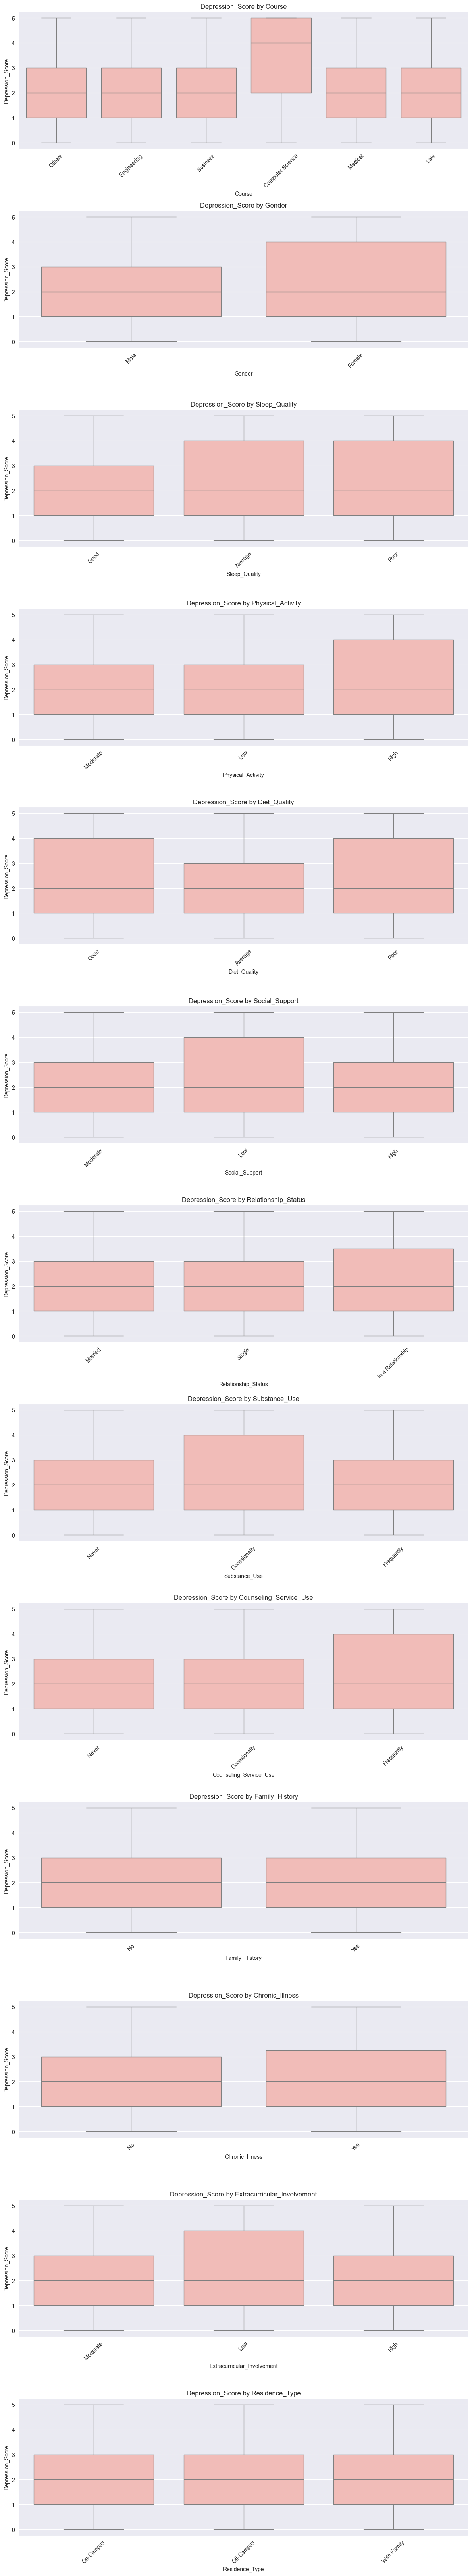

In [15]:
# Check if 'Stress_Score' column exists (adjust name if different)
# Common variations: 'Stress_Score', 'stress_score', 'Stress Score', etc.
print(dataset.columns)

# Assuming the stress score column exists, let's analyze relationships
Depression_col = 'Depression_Score'  # Adjust this to your actual column name

# 1. Correlation with stress score
numeric_data = dataset.select_dtypes(include=[np.number])
stress_correlations = numeric_data.corr()[Depression_col].sort_values(ascending=False)
print("\nCorrelations with Depression Score:")
print(stress_correlations)

# 2. Visualize correlations
plt.figure(figsize=(10, 6))
stress_correlations.drop(Depression_col).plot(kind='barh')
plt.title(f'Correlation of Features with {Depression_col}')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# 3. Scatter plots of top correlated features
top_features = stress_correlations.drop(Depression_col).abs().nlargest(5).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    sns.scatterplot(data=dataset, x=feature, y=Depression_col, ax=axes[idx])
    axes[idx].set_title(f'{feature} vs {Depression_col}')

plt.tight_layout()
plt.show()

# 4. Box plots for categorical variables (if any)
categorical_cols = dataset.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5*len(categorical_cols)))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        sns.boxplot(data=dataset, x=col, y=Depression_col, ax=axes[idx])
        axes[idx].set_title(f'{Depression_col} by {col}')
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()

Index(['Student_ID', 'Age', 'Course', 'Gender', 'CGPA', 'Stress_Level',
       'Depression_Score', 'Anxiety_Score', 'Sleep_Quality',
       'Physical_Activity', 'Diet_Quality', 'Social_Support',
       'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use',
       'Family_History', 'Chronic_Illness', 'Financial_Stress',
       'Extracurricular_Involvement', 'Semester_Credit_Load',
       'Residence_Type'],
      dtype='object')

Correlations with Anxiety Score:
Anxiety_Score           1.000000
Semester_Credit_Load    0.010819
Age                     0.008618
CGPA                    0.003504
Student_ID              0.002849
Financial_Stress       -0.003994
Depression_Score       -0.018019
Stress_Level           -0.035802
Name: Anxiety_Score, dtype: float64


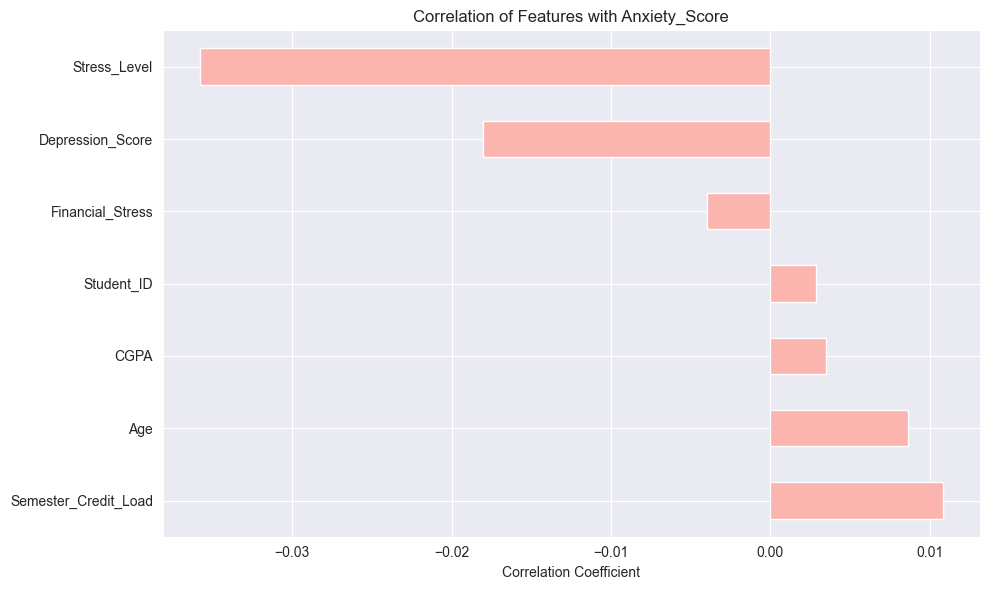

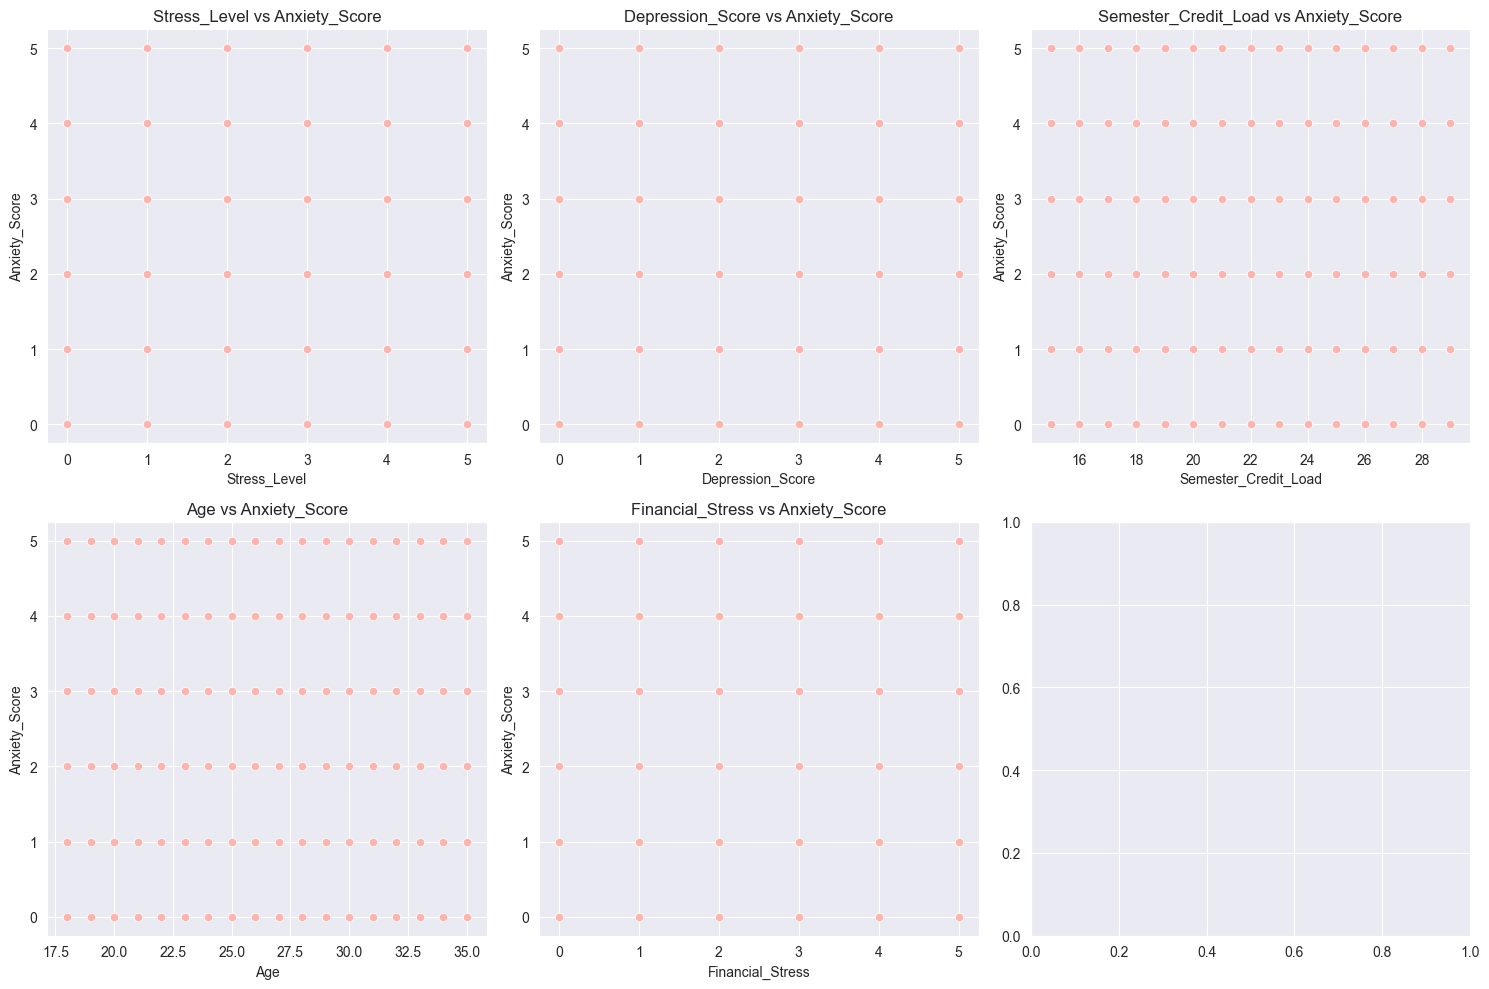

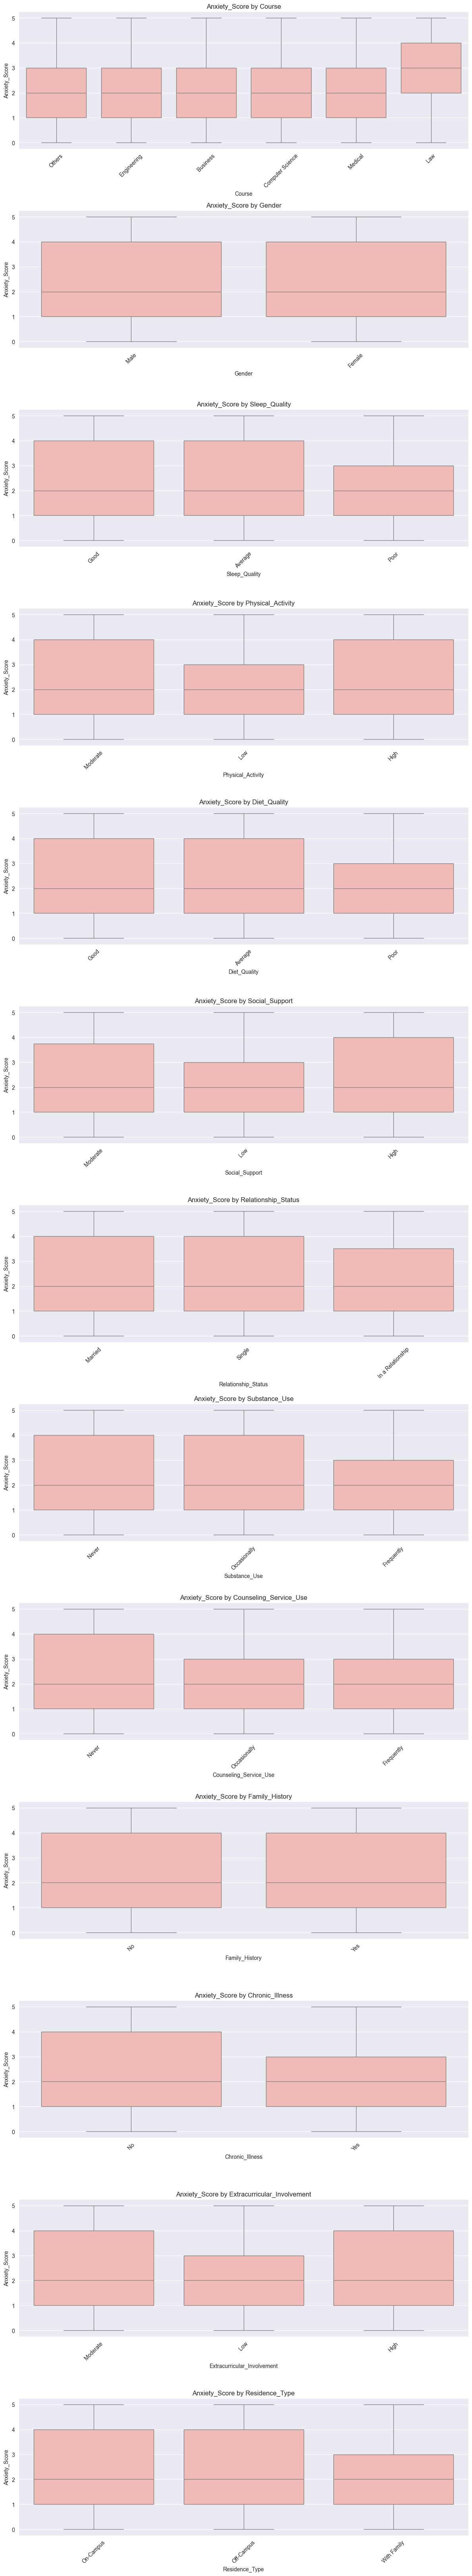

In [16]:
# Check if 'Anxiety_Score' column exists (adjust name if different)
print(dataset.columns)

# Assuming the anxiety score column exists, let's analyze relationships
Anxiety_col = 'Anxiety_Score'  # Adjust this to your actual column name

# 1. Correlation with anxiety score
numeric_data = dataset.select_dtypes(include=[np.number])
anxiety_correlations = numeric_data.corr()[Anxiety_col].sort_values(ascending=False)
print("\nCorrelations with Anxiety Score:")
print(anxiety_correlations)

# 2. Visualize correlations
plt.figure(figsize=(10, 6))
anxiety_correlations.drop(Anxiety_col).plot(kind='barh')
plt.title(f'Correlation of Features with {Anxiety_col}')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# 3. Scatter plots of top correlated features
top_features = anxiety_correlations.drop(Anxiety_col).abs().nlargest(5).index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    sns.scatterplot(data=dataset, x=feature, y=Anxiety_col, ax=axes[idx])
    axes[idx].set_title(f'{feature} vs {Anxiety_col}')

plt.tight_layout()
plt.show()

# 4. Box plots for categorical variables (if any)
categorical_cols = dataset.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5*len(categorical_cols)))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(categorical_cols):
        sns.boxplot(data=dataset, x=col, y=Anxiety_col, ax=axes[idx])
        axes[idx].set_title(f'{Anxiety_col} by {col}')
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()